# Regression for Biochemsitry
We will look at regression for biochemistry, using the Promelt dataset

# Install packages
Only run if you do not already have these packages

In [ ]:
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

# Load and process data
We will process the data the same way we did for classification, except this time we will not set a threshold because we want to predict the continuous value for stability

In [1]:
import pandas as pd
import numpy as np

#counts the number of times an amino acid occurs in the sequence
def count_amino_acid(seq, amino_acid):
    return seq.count(amino_acid)

df = pd.read_csv("full_promelt_seq.csv")
#remove rows with invalid amino acids
df = df[df["sequence"].str.count("X")==0]
df = df[df["sequence"].str.count("U")==0]
df = df[df["sequence"].str.count("Z")==0]
df = df[df["sequence"].str.count("B")==0]

#remove rows with very long sequences
df = df[df["Length"]<1000]

#this will use the string count function on all items in the sequence column (similar to the apply we covered before)
df["A_frac"] = df["sequence"].str.count('A')/df["Length"]
df["C_frac"] = df["sequence"].str.count('C')/df["Length"]
df["D_frac"] = df["sequence"].str.count('D')/df["Length"]
df["E_frac"] = df["sequence"].str.count('E')/df["Length"]
df["F_frac"] = df["sequence"].str.count('F')/df["Length"]
df["G_frac"] = df["sequence"].str.count('G')/df["Length"]
df["H_frac"] = df["sequence"].str.count('H')/df["Length"]
df["I_frac"] = df["sequence"].str.count('I')/df["Length"]
df["K_frac"] = df["sequence"].str.count('K')/df["Length"]
df["L_frac"] = df["sequence"].str.count('L')/df["Length"]
df["M_frac"] = df["sequence"].str.count('M')/df["Length"]
df["N_frac"] = df["sequence"].str.count('N')/df["Length"]
df["P_frac"] = df["sequence"].str.count('P')/df["Length"]
df["Q_frac"] = df["sequence"].str.count('Q')/df["Length"]
df["R_frac"] = df["sequence"].str.count('R')/df["Length"]
df["S_frac"] = df["sequence"].str.count('S')/df["Length"]
df["T_frac"] = df["sequence"].str.count('T')/df["Length"]
df["V_frac"] = df["sequence"].str.count('V')/df["Length"]
df["W_frac"] = df["sequence"].str.count('W')/df["Length"]
df["Y_frac"] = df["sequence"].str.count('Y')/df["Length"]


# Split data into training and test
We will split our data into training and test data. We will do this randomly for now. Note that for testing that better assesses model generlizability, you would want to split by scaffold. Again, this will be the same as for a classification

In [2]:
from sklearn.model_selection import train_test_split

#this will put 20% of the data into the test set
#note that the random state needs to be set to make sure it is split consistently between runs
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Linear regression
This is the same as any linear regression you would do, but here we can have more than one x-variable, it is fit by minimizing the residual sum of squares between the true and predicted values. Let's try fitting a linear regression using different amino acid counts as our features. We will assess the accuracy of our regression by calculating mean absolute error (MAE), root mean square erorr (RMSE), pearson's correlation (r), and R2 score. We can also plot true vs predicted values, if the prediction is very accurate, it should show a linear relationship because predicted=true. For MAE and RMSE, lower is better, for pearson's correlation and R2 score you want a high positive value (maximum 1).
Which models are the most accurate? Which are more overfit?

Train Q fraction MAE: 7.210836375587883
Train Q fraction RMSE: 10.266366882439364
Train Q fraction R-squared: 0.051325104060910176
Train Q fraction Pearson's r: PearsonRResult(statistic=0.22655044484818437, pvalue=0.0)
Test Q fraction MAE: 7.1316373560518675
Test Q fraction RMSE: 10.123428200817063
Test Q fraction R-squared: 0.05141686112647803
Test Q fraction Pearson's r: PearsonRResult(statistic=0.2268863536219005, pvalue=3.3481349070371916e-88)


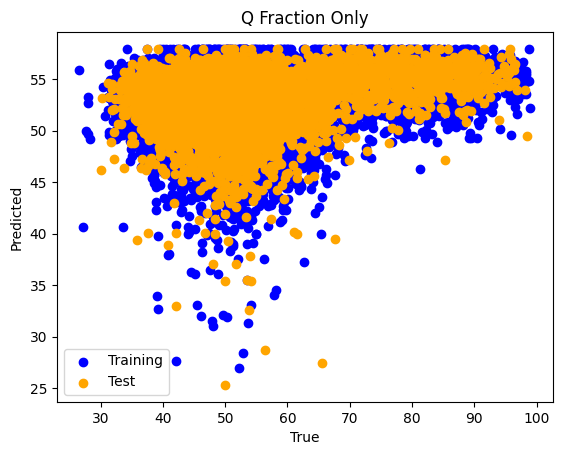

Train Q and G frac MAE: 7.174393499544396
Train Q and G frac RMSE: 10.146589666242187
Train Q and G frac R-squared: 0.07333226269885329
Train Q and G frac Pearson's r: PearsonRResult(statistic=0.2707993033574002, pvalue=0.0)
Test Q and G frac MAE: 7.100424059988325
Test Q and G frac RMSE: 10.005384628143297
Test Q and G frac R-squared: 0.07340966966868889
Test Q and G frac Pearson's r: PearsonRResult(statistic=0.27098236903486056, pvalue=2.0182642177306496e-126)


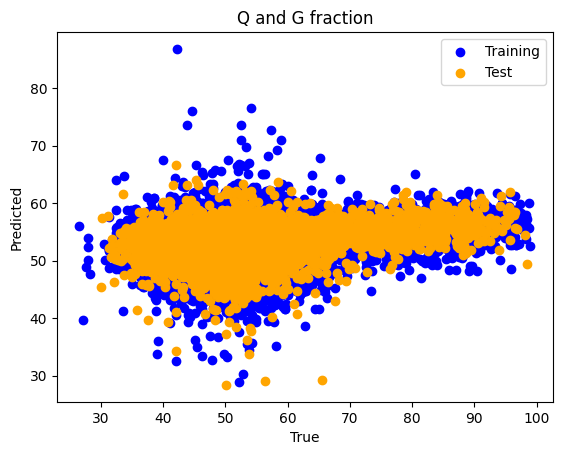

Train All AA MAE: 6.808463107401113
Train All AA RMSE: 8.979299805034799
Train All AA R-squared: 0.2742805008299626
Train All AA Pearson's r: PearsonRResult(statistic=0.523722611213616, pvalue=0.0)
Test All AA MAE: 6.740879269625484
Test All AA RMSE: 8.876443783936786
Test All AA R-squared: 0.27071345579942696
Test All AA Pearson's r: PearsonRResult(statistic=0.5203484160507905, pvalue=0.0)


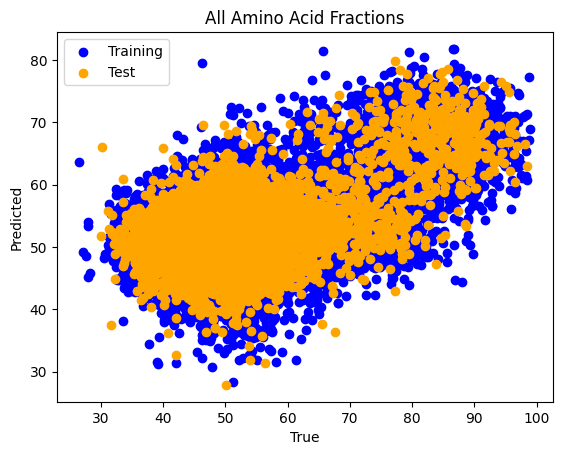

In [4]:
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

reg_q = linear_model.LinearRegression()
reg_q.fit(train_df[["Q_frac"]],train_df["Tm"])
train_q_pred = reg_q.predict(train_df[["Q_frac"]])
test_q_pred = reg_q.predict(test_df[["Q_frac"]])
print("Train Q fraction MAE: " + str(mean_absolute_error(train_df["Tm"],train_q_pred)))
print("Train Q fraction RMSE: " + str(root_mean_squared_error(train_df["Tm"],train_q_pred)))
print("Train Q fraction R-squared: " + str(r2_score(train_df["Tm"],train_q_pred)))
print("Train Q fraction Pearson's r: " + str(pearsonr(train_df["Tm"],train_q_pred)))
print("Test Q fraction MAE: " + str(mean_absolute_error(test_df["Tm"],test_q_pred)))
print("Test Q fraction RMSE: " + str(root_mean_squared_error(test_df["Tm"],test_q_pred)))
print("Test Q fraction R-squared: " + str(r2_score(test_df["Tm"],test_q_pred)))
print("Test Q fraction Pearson's r: " + str(pearsonr(test_df["Tm"],test_q_pred)))

# Create a scatter plot
plt.scatter(train_df["Tm"], train_q_pred, color='blue', label='Training')
plt.scatter(test_df["Tm"], test_q_pred,color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Q Fraction Only')

# Display the plot
plt.show()

reg_2aa = linear_model.LinearRegression()
reg_2aa.fit(train_df[["Q_frac","G_frac"]],train_df["Tm"])
train_2aa_pred = reg_2aa.predict(train_df[["Q_frac","G_frac"]])
test_2aa_pred = reg_2aa.predict(test_df[["Q_frac","G_frac"]])
print("Train Q and G frac MAE: " + str(mean_absolute_error(train_df["Tm"],train_2aa_pred)))
print("Train Q and G frac RMSE: " + str(root_mean_squared_error(train_df["Tm"],train_2aa_pred)))
print("Train Q and G frac R-squared: " + str(r2_score(train_df["Tm"],train_2aa_pred)))
print("Train Q and G frac Pearson's r: " + str(pearsonr(train_df["Tm"],train_2aa_pred)))
print("Test Q and G frac MAE: " + str(mean_absolute_error(test_df["Tm"],test_2aa_pred)))
print("Test Q and G frac RMSE: " + str(root_mean_squared_error(test_df["Tm"],test_2aa_pred)))
print("Test Q and G frac R-squared: " + str(r2_score(test_df["Tm"],test_2aa_pred)))
print("Test Q and G frac Pearson's r: " + str(pearsonr(test_df["Tm"],test_2aa_pred)))

# Create a scatter plot
plt.scatter(train_df["Tm"], train_2aa_pred,color='blue', label='Training')
plt.scatter(test_df["Tm"], test_2aa_pred, color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Q and G fraction')

# Display the plot
plt.show()

reg_all_aa = linear_model.LinearRegression()
reg_all_aa.fit(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]],train_df["Tm"])
train_all_aa_pred = reg_all_aa.predict(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])
test_all_aa_pred = reg_all_aa.predict(test_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])
print("Train All AA MAE: " + str(mean_absolute_error(train_df["Tm"],train_all_aa_pred)))
print("Train All AA RMSE: " + str(root_mean_squared_error(train_df["Tm"],train_all_aa_pred)))
print("Train All AA R-squared: " + str(r2_score(train_df["Tm"],train_all_aa_pred)))
print("Train All AA Pearson's r: " + str(pearsonr(train_df["Tm"],train_all_aa_pred)))
print("Test All AA MAE: " + str(mean_absolute_error(test_df["Tm"],test_all_aa_pred)))
print("Test All AA RMSE: " + str(root_mean_squared_error(test_df["Tm"],test_all_aa_pred)))
print("Test All AA R-squared: " + str(r2_score(test_df["Tm"],test_all_aa_pred)))
print("Test All AA Pearson's r: " + str(pearsonr(test_df["Tm"],test_all_aa_pred)))

# Create a scatter plot
plt.scatter(train_df["Tm"],train_all_aa_pred,color='blue', label='Training')
plt.scatter(test_df["Tm"],test_all_aa_pred,color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('All Amino Acid Fractions')

# Display the plot
plt.show()

# Linear regression with one hot encoding
Note that the 20 amino acid fractions are not enough features to result in severe overfitting with linear regression (if you compare to the fingerprint example in the chemistry notebook). To demonstrate this we will use a one hot encoding of the sequence which will result in significantly more features. Because the one hot encoding is very large, the regression takes longer to fit, so we will also limit the amount of training data used, which will further worsen overfitting.

Train OHE MAE: 0.009122123092796358
Train OHE RMSE: 0.08735716839250661
Train OHE R-squared: 0.9999345775026589
Train OHE Pearson's r: PearsonRResult(statistic=0.9999672922994381, pvalue=0.0)
Test OHE MAE: 3703.738458386052
Test OHE RMSE: 4958.192800318987
Test OHE R-squared: -227543.84836728478
Test OHE Pearson's r: PearsonRResult(statistic=-0.033471515147454, pvalue=0.003736066183902311)


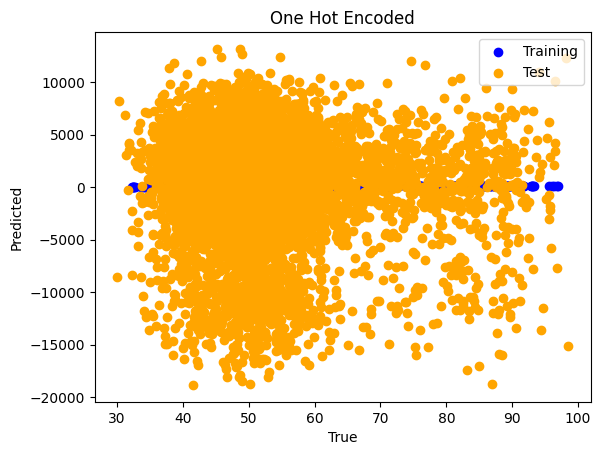

In [6]:
import numpy as np

# Standard 20 amino acids
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}


def one_hot_encode_proteins(df, sequence_col="sequence",max_length=None):
    """
    One-hot encode protein sequences in a pandas DataFrame. Specify sequence_col if it is not sequence

    returns a one-hot encoded numpy array with the maximum sequence length in the dataframe if max_length=None and the 
    specified length otherwise
    Mask is another array that indicates if a position is encoded or padding beyond the length of the sequence
    """

    sequences = df[sequence_col].astype(str).str.upper().tolist()

    # Determine maximum length
    if max_length is None:
        max_length = max(len(seq) for seq in sequences)
    #this handles if an invalid max_length is sent to the method
    elif not isinstance(max_length, int) or max_length <= 0:
        raise ValueError("max_length must be a positive integer or None.")

    encoded = np.zeros(
        (len(sequences), max_length, len(AMINO_ACIDS)),
        dtype=np.float32
    )

    mask = np.zeros(
        (len(sequences), max_length),
        dtype=bool
    )

    for i, seq in enumerate(sequences):
        # Truncate sequence if necessary
        seq = seq[:max_length]

        for j, aa in enumerate(seq):
            if aa not in aa_to_idx:
                raise ValueError(
                    f"Unknown amino acid '{aa}' in sequence {i} "
                    f"at position {j}"
                )

            encoded[i, j, aa_to_idx[aa]] = 1.0

        # Mark actual sequence positions
        mask[i, :len(seq)] = True

    return encoded, mask

train_ohe, mask_ohe = one_hot_encode_proteins(train_df[1:2000])
test_ohe, mask_test = one_hot_encode_proteins(test_df,max_length=train_ohe.shape[1])

reg_ohe = linear_model.LinearRegression()
#one hot encoding needs to be a 1D vector, we can do that with reshape. The -1 indicates the second two dimensions should be flattened
reg_ohe.fit(train_ohe.reshape(train_ohe.shape[0], -1),train_df["Tm"][1:2000])
train_ohe_pred = reg_ohe.predict(train_ohe.reshape(train_ohe.shape[0], -1))
test_ohe_pred = reg_ohe.predict(test_ohe.reshape(test_ohe.shape[0], -1))
print("Train OHE MAE: " + str(mean_absolute_error(train_df["Tm"][1:2000],train_ohe_pred)))
print("Train OHE RMSE: " + str(root_mean_squared_error(train_df["Tm"][1:2000],train_ohe_pred)))
print("Train OHE R-squared: " + str(r2_score(train_df["Tm"][1:2000],train_ohe_pred)))
print("Train OHE Pearson's r: " + str(pearsonr(train_df["Tm"][1:2000],train_ohe_pred)))
print("Test OHE MAE: " + str(mean_absolute_error(test_df["Tm"],test_ohe_pred)))
print("Test OHE RMSE: " + str(root_mean_squared_error(test_df["Tm"],test_ohe_pred)))
print("Test OHE R-squared: " + str(r2_score(test_df["Tm"],test_ohe_pred)))
print("Test OHE Pearson's r: " + str(pearsonr(test_df["Tm"],test_ohe_pred)))

# Create a scatter plot
plt.scatter(train_df["Tm"][1:2000],train_ohe_pred,color='blue', label='Training')
plt.scatter(test_df["Tm"],test_ohe_pred,color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('One Hot Encoded')

# Display the plot
plt.show()


# Ridge, Lasso, and ElasticNet
We can see above that the one hot encoded model is very overfit, because the ohe matrix is so large. We can use ridge, lasso, and elasticnet regression to avoid overfitting.

Ridge FP MAE: 8.73787076663093
Lasso FP MAE: 7.039244661039718
ElasticNet FP MAE: 7.030477230962595


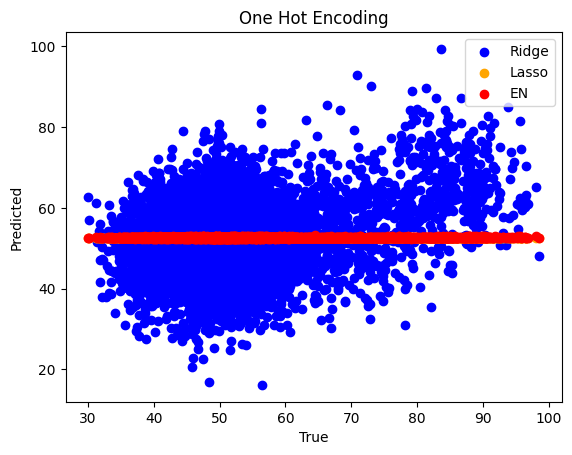

In [8]:
from sklearn import linear_model

ridge = linear_model.Ridge(alpha=.5) #alpha sets the strength of the Ridge penalty, try adjusting it and see how it affects results
ridge.fit(train_ohe.reshape(train_ohe.shape[0], -1),train_df["Tm"][1:2000])
ridge_test_predict = ridge.predict(test_ohe.reshape(test_ohe.shape[0], -1))

lasso = linear_model.Lasso(alpha=0.5) #try adjusting alpha
lasso.fit(train_ohe.reshape(train_ohe.shape[0], -1),train_df["Tm"][1:2000])
lasso_test_predict = lasso.predict(test_ohe.reshape(test_ohe.shape[0], -1))

en = linear_model.ElasticNet(alpha=0.5,l1_ratio=0.5) #try adjusting alpha and l1 ratio (controls balance between lasso + ridge)
en.fit(train_ohe.reshape(train_ohe.shape[0], -1),train_df["Tm"][1:2000])
en_test_predict = en.predict(test_ohe.reshape(test_ohe.shape[0], -1))

#calculate MAE metric
print("Ridge FP MAE: " + str(mean_absolute_error(test_df["Tm"],ridge_test_predict)))
print("Lasso FP MAE: " + str(mean_absolute_error(test_df["Tm"],lasso_test_predict)))
print("ElasticNet FP MAE: " + str(mean_absolute_error(test_df["Tm"],en_test_predict)))

plt.scatter(test_df["Tm"],ridge_test_predict,color='blue', label='Ridge')
plt.scatter(test_df["Tm"],lasso_test_predict,color='orange', label='Lasso')
plt.scatter(test_df["Tm"],en_test_predict,color='red', label='EN')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('One Hot Encoding')

# Display the plot
plt.show()

# Support Vector Machine
Like with SVM classifiers, we can have different kernels, let's compare and see which works best for our stability prediction, we will go back to amino acid counts to make training faster

RBF FP MAE: 6.454739938019137
Linear FP MAE: 6.509271231732337
Poly FP MAE: 6.4981505921829115


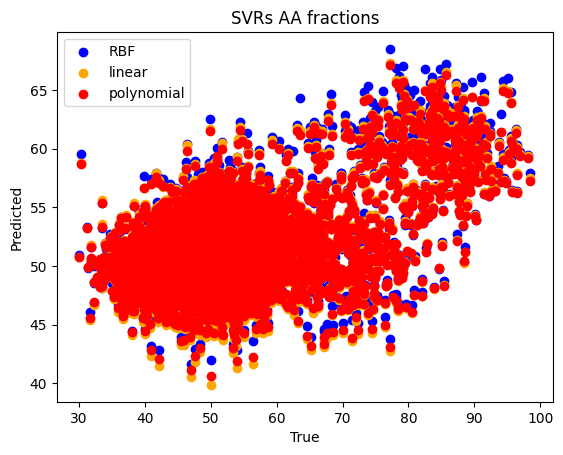

In [11]:
from sklearn.svm import SVR

#you can try adjusting gamma and epsilon to see how accuracy is affected
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr_lin = SVR(kernel="linear", C=100, gamma="auto")
svr_poly = SVR(kernel="poly", C=100, gamma="auto", degree=3, epsilon=0.1, coef0=1)

#fit models
svr_rbf.fit(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]],train_df["Tm"])
svr_lin.fit(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]],train_df["Tm"])
svr_poly.fit(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]],train_df["Tm"])

#predict
rbf_test_predict = svr_rbf.predict(test_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])
lin_test_predict = svr_lin.predict(test_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])
poly_test_predict = svr_poly.predict(test_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])

#MAE metric
print("RBF FP MAE: " + str(mean_absolute_error(test_df["Tm"],rbf_test_predict)))
print("Linear FP MAE: " + str(mean_absolute_error(test_df["Tm"],lin_test_predict)))
print("Poly FP MAE: " + str(mean_absolute_error(test_df["Tm"],poly_test_predict)))

#plot
plt.scatter(test_df["Tm"],rbf_test_predict,color='blue', label='RBF')
plt.scatter(test_df["Tm"],lin_test_predict,color='orange', label='linear')
plt.scatter(test_df["Tm"],poly_test_predict,color='red', label='polynomial')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('SVRs AA fractions')

# Display the plot
plt.show()

# Random forest regression

RFR MAE: 5.3773833249684255


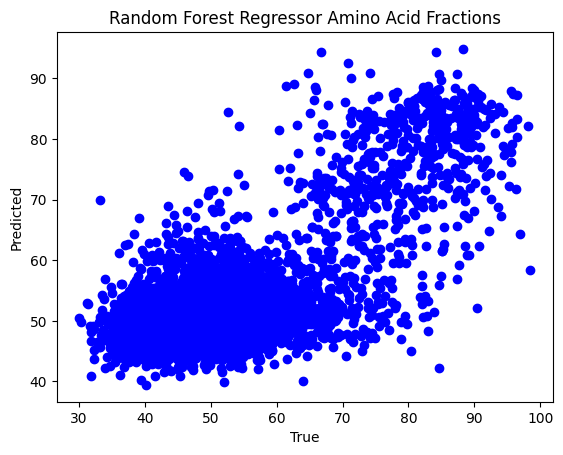

In [5]:
from sklearn.ensemble import RandomForestRegressor

#Random forest regressor using fingerprints as features
rfr = RandomForestRegressor(n_estimators=10)
rfr.fit(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]],train_df["Tm"])
rfr_test_predict = rfr.predict(test_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])

#MAE metric
print("RFR MAE: " + str(mean_absolute_error(test_df["Tm"],rfr_test_predict)))
#plot
plt.scatter(test_df["Tm"],rfr_test_predict,color='blue')


# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Random Forest Regressor Amino Acid Fractions')

# Display the plot
plt.show()

# GridSearchCV for regression
Grid search works similarly to classificaiton case, just need to choose an appropriate metric. RMSE or MSE are good choices depending on if your data has outliers. MSE better for outliers because the square difference on the outlier will not overpower other errors. Note you will need to make them use the negative version of these scores so that the higher scoring models are better because GridSearchCV selects the model with the highest score.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}

Best CV neg RMSE:
-7.066158967741119
Optimized MAE: 5.098562345065783
Optimized RMSE: 6.930594462471016


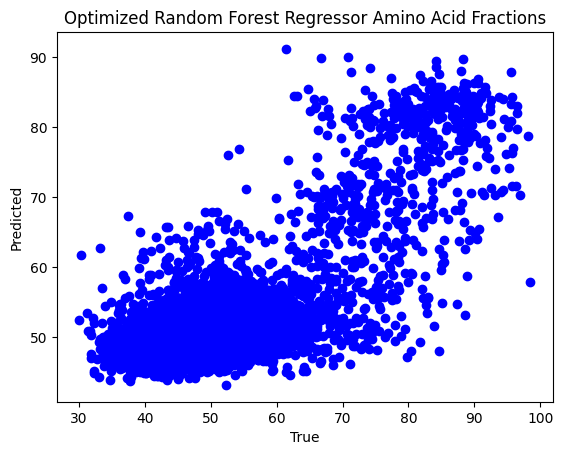

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

#recreate the random forest regressor without any hyperparameters set
random_forest_regressor = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

#define the grid of parameters you want to test the combinations of
param_grid = {
    "n_estimators": [10, 30, 50],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2"],
}


#set up the grid,we need to give it our classifier, our grid, scoring, and cross validation method 
grid = GridSearchCV(
    estimator=random_forest_regressor,
    param_grid=param_grid,
    scoring={
        "neg_root_mean_squared_error": "neg_root_mean_squared_error",
        "neg_mean_absolute_error": "neg_mean_absolute_error"
    },
    refit="neg_root_mean_squared_error",      # refit best model based on RMSE
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(train_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]], train_df["Tm"])

# best model
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV neg RMSE:")
print(grid.best_score_)

best_model = grid.best_estimator_

#evaluate on test data
y_pred = best_model.predict(test_df[["A_frac","C_frac","D_frac","E_frac","F_frac","G_frac","H_frac","I_frac","K_frac","L_frac","M_frac","N_frac",\
                               "P_frac","Q_frac","R_frac","S_frac","T_frac","V_frac","W_frac","Y_frac"]])

#MAE metric
print("Optimized MAE: " + str(mean_absolute_error(test_df["Tm"],y_pred)))
print("Optimized RMSE: " + str(root_mean_squared_error(test_df["Tm"],y_pred)))
#plot
plt.scatter(test_df["Tm"],y_pred,color='blue')


# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Optimized Random Forest Regressor Amino Acid Fractions')

# Display the plot
plt.show()